## Implementation of basic Persistence workflow - checkpointer 

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START,END
from langgraph.checkpoint.memory import InMemorySaver # InMemorySaver used to save temporary to RAM for demo purpose
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import os

load_dotenv()

True

In [3]:
model = ChatGoogleGenerativeAI(api_key=os.getenv("GOOGLE_API_KEY"), model="gemini-2.5-flash-lite", temperature=0)

In [4]:
class JokeState(BaseModel):
    topic:str = ""
    joke:str = ""
    explanation:str = ""

In [10]:
def joke_generate(state:JokeState)-> dict:
    prompt_joke = f"Tell me a joke about {state.topic} in one sentence."
    joke = model.invoke(prompt_joke)
    return {'joke': joke.text}


def joke_explain(state:JokeState)-> dict:
    prompt_explain = f"Explain the following joke: {state.joke} in one sentence."
    explanation = model.invoke(prompt_explain)
    return {'explanation': explanation.text}

In [11]:
graph = StateGraph(JokeState)

# add nodes 
graph.add_node('joke_generate',joke_generate)
graph.add_node('joke_explain',joke_explain)


# add edges
graph.add_edge(START,'joke_generate')
graph.add_edge('joke_generate','joke_explain')
graph.add_edge('joke_explain',END)

# add checkpoint saver
chekkpointer = InMemorySaver() # creating object of class InMemorySaver 
# InMemorySaver is a temporary saver that saves the state in memory (RAM).
# For production use, consider using a persistent saver like DatabaseSaver or FileSaver.

joker_workflow = graph.compile(checkpointer=chekkpointer)


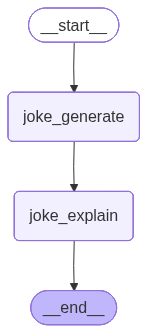

In [8]:
joker_workflow

In [12]:
config_state = {
    "configurable":{"thread_id":"1"}
}

initial_state = {
    'topic': 'technology'
}

final_state = joker_workflow.invoke(initial_state,config=config_state)

In [13]:
final_state

{'topic': 'technology',
 'joke': 'Why did the computer go to therapy? Because it had too many unresolved issues and a serious case of the bluescreen.',
 'explanation': 'The joke plays on the double meaning of "issues" as both problems and emotional problems, and "bluescreen" as a computer error and a feeling of sadness.'}

#### Persistence 

In [15]:
# get_state used to get the final state after workflow execution snapshot of final state

joker_workflow.get_state(config_state)

StateSnapshot(values={'topic': 'technology', 'joke': 'Why did the computer go to therapy? Because it had too many unresolved issues and a serious case of the bluescreen.', 'explanation': 'The joke plays on the double meaning of "issues" as both problems and emotional problems, and "bluescreen" as a computer error and a feeling of sadness.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0f16bb-8604-6bed-8002-a3ab8bd86476'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-01-14T17:09:00.559870+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0f16bb-7ed5-6be4-8001-4a895ef94b3c'}}, tasks=(), interrupts=())

In [ ]:
# get_state_history used to get the history of states during workflow execution snapshot of state history
list(joker_workflow.get_state_history(config_state))

# You use list() because the get_state_history method in LangGraph returns a Generator (Iterator), not a ready-made list.
# In Python terms, the method is "lazy"—it is designed to stream the history items one by one rather than loading them all into memory at once.

# -------- without list ------------
# history = joker_workflow.get_state_history(config_state)
# print(history)
# Output: <generator object Pregel.get_state_history at 0x104...>
# (You can't see the actual checkpoints!)

# To see the actual checkpoints, you need to convert the generator to a list:
# history_list = list(history)
# print(history_list)
# Output: [JokeState(topic='technology', joke='...', explanation='...'), ...


[StateSnapshot(values={'topic': 'technology', 'joke': 'Why did the computer go to therapy? Because it had too many unresolved issues and a serious case of the bluescreen.', 'explanation': 'The joke plays on the double meaning of "issues" as both problems and emotional problems, and "bluescreen" as a computer error and a feeling of sadness.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0f16bb-8604-6bed-8002-a3ab8bd86476'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-01-14T17:09:00.559870+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0f16bb-7ed5-6be4-8001-4a895ef94b3c'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'technology', 'joke': 'Why did the computer go to therapy? Because it had too many unresolved issues and a serious case of the bluescreen.'}, next=('joke_explain',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'ch